# Task 9: Hydrogen Tweet Classification with BERT

This notebook covers the end-to-end pipeline for Task 9:
1. Data Preprocessing & Exploration
2. Baseline Model: Logistic Regression using TF-IDF features
3. Fine-tuning BERT Model 1 (`bert-base-uncased`)
4. Fine-tuning BERT Model 2 (`vinai/bertweet-base`)
5. Model Evaluation and Comparison (Accuracy, Classification Report, ROC Curve)
6. Attention Weights Analysis & Visualisation

## 1. Environment Setup & Library Imports

In [1]:
#%pip install matplotlib seaborn scikit-learn

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    roc_auc_score,
    roc_curve
)

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Data Preprocessing & Cleaning

In [3]:
# Load raw tweets dataset
df = pd.read_csv('hydrogen_small.csv')
print("Shape of dataset:", df.shape)
print(df.head())

text_col = 'Text' if 'Text' in df.columns else 'text'
label_col = 'Label' if 'Label' in df.columns else 'label'

print(f"\nClass distribution in {label_col}:")
print(df[label_col].value_counts())

Shape of dataset: (1000, 2)
        label                                               text
0    Relevant         behind the wheel of a hydrogen powered car
1  Irrelevant  mls measurements of stratospheric hydrogen cya...
2    Relevant  ana gonzalez hernandez shares an overview of h...
3    Relevant  toyota is giving away its first hydrogen car i...
4    Relevant  agility develops storage systems for hydrogen ...

Class distribution in label:
label
Relevant      547
Irrelevant    453
Name: count, dtype: int64


In [4]:
# Text cleaning function adapted from Module 8 practical
def clean_message(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # Remove URLs
    text = re.sub(r"@\w+", "", text)                     # Remove tags
    text = re.sub(r"[^\x00-\x7F]+", "", text)            # Remove non-ASCII
    text = re.sub(r"\s+", " ", text)                     # Consecutive whitespace to single space
    return text.strip()

df['cleaned_text'] = df[text_col].apply(clean_message)

# Map labels to binary values (1: Relevant, 0: Irrelevant)
label_mapping = {}
for val in df[label_col].unique():
    if str(val).lower() in ['relevant', '1', '1.0', 'true']:
        label_mapping[val] = 1
    else:
        label_mapping[val] = 0

df['target'] = df[label_col].map(label_mapping)
print("Mapped class distribution:")
print(df['target'].value_counts())

Mapped class distribution:
target
1    547
0    453
Name: count, dtype: int64


In [5]:
# Stratified Train/Test Split (70% Train, 30% Test)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['cleaned_text'].tolist(),
    df['target'].tolist(),
    test_size=0.3,
    stratify=df['target'].tolist(),
    random_state=42
)

print(f"Training instances: {len(X_train_raw)}, Testing instances: {len(X_test_raw)}")

Training instances: 700, Testing instances: 300


## 3. Baseline Model: Logistic Regression with TF-IDF Features

In [6]:
# Load pre-extracted TF-IDF features
tfidf_df = pd.read_csv('tfidf_features_small.csv')
print("TF-IDF features shape:", tfidf_df.shape)

if label_col in tfidf_df.columns:
    X_tfidf = tfidf_df.drop(columns=[label_col]).values
else:
    X_tfidf = tfidf_df.values

y_all = df['target'].values

# Sanity check: tfidf_features_small.csv has no shared ID column with hydrogen_small.csv,
# so row alignment between the two files is an assumption, not a guarantee. Verify it by
# checking that in-vocabulary words from each sampled tweet have nonzero TF-IDF weight in
# that same row index (a misaligned file would score close to 0, not ~1.0).
tfidf_cols = set(tfidf_df.columns) - ({label_col} if label_col in tfidf_df.columns else set())
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(df), size=30, replace=False)
match_rates = []
for idx in sample_idx:
    words = set(re.findall(r"[a-z]+", df.loc[idx, 'cleaned_text'].lower()))
    words = {w for w in words if w in tfidf_cols}
    if not words:
        continue
    nonzero = sum(tfidf_df.loc[idx, w] > 0 for w in words)
    match_rates.append(nonzero / len(words))

avg_match = np.mean(match_rates)
print(f"Row-alignment check: {avg_match:.1%} of in-vocabulary words from sampled tweets have "
      f"nonzero TF-IDF weight in the matching row (expect ~100% if rows are aligned).")
if avg_match < 0.9:
    print("WARNING: tfidf_features_small.csv does not appear row-aligned with hydrogen_small.csv "
          "-- baseline results below may be invalid.")

X_train_tfidf, X_test_tfidf, y_train_bl, y_test_bl = train_test_split(
    X_tfidf,
    y_all,
    test_size=0.3,
    stratify=y_all,
    random_state=42
)

# Train Logistic Regression baseline
baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
baseline_lr.fit(X_train_tfidf, y_train_bl)

y_pred_bl = baseline_lr.predict(X_test_tfidf)
y_prob_bl = baseline_lr.predict_proba(X_test_tfidf)[:, 1]

bl_acc = accuracy_score(y_test_bl, y_pred_bl)
print(f"Baseline Logistic Regression Accuracy: {bl_acc:.4f}")
print("\nClassification Report (Baseline LR):")
print(classification_report(y_test_bl, y_pred_bl, target_names=['Irrelevant', 'Relevant']))

TF-IDF features shape: (1000, 4981)
Row-alignment check: 100.0% of in-vocabulary words from sampled tweets have nonzero TF-IDF weight in the matching row (expect ~100% if rows are aligned).
Baseline Logistic Regression Accuracy: 0.8967

Classification Report (Baseline LR):
              precision    recall  f1-score   support

  Irrelevant       0.96      0.80      0.88       136
    Relevant       0.86      0.98      0.91       164

    accuracy                           0.90       300
   macro avg       0.91      0.89      0.89       300
weighted avg       0.91      0.90      0.90       300



## 4. Helper Function for BERT Metrics

In [7]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    prec, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', pos_label=1)
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': recall,
        'f1': f1
    }

## 5. Fine-Tuning Model 1: `bert-base-uncased`

In [8]:
m1_name = "bert-base-uncased"
tokenizer_m1 = AutoTokenizer.from_pretrained(m1_name)

train_ds_m1 = Dataset.from_pandas(pd.DataFrame({'text': X_train_raw, 'label': y_train}))
test_ds_m1 = Dataset.from_pandas(pd.DataFrame({'text': X_test_raw, 'label': y_test}))

def tokenize_m1(batch):
    return tokenizer_m1(batch['text'], truncation=True, max_length=128)

train_ds_m1 = train_ds_m1.map(tokenize_m1, batched=True)
test_ds_m1 = test_ds_m1.map(tokenize_m1, batched=True)

model_m1 = AutoModelForSequenceClassification.from_pretrained(m1_name, num_labels=2)

args_m1 = TrainingArguments(
    output_dir="./results_bert_base",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

trainer_m1 = Trainer(
    model=model_m1,
    args=args_m1,
    train_dataset=train_ds_m1,
    eval_dataset=test_ds_m1,
    processing_class=tokenizer_m1,
    data_collator=DataCollatorWithPadding(tokenizer_m1),
    compute_metrics=compute_metrics
)

print("Fine-tuning bert-base-uncased...")
trainer_m1.train()

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning bert-base-uncased...


...

C:\Users\Dmitry.Novik\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

[transformers] There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta', 'bert.encoder.layer.1.attention.output.LayerNorm.gamma', 'bert.encoder.layer.1.output.LayerNorm.beta', 'bert.encoder.layer.1.output.LayerNorm.gamma', 'bert.encoder.layer.2.attention.output.LayerNorm.beta', 'bert.encoder.layer.2.attention.output.LayerNorm.gamma', 'bert.encoder.layer.2.output.LayerNorm.beta', 'bert.encoder.layer.2.output.LayerNorm.gamma', 'bert.encoder.layer.3.attention.output.LayerNorm.beta', 'bert.encoder.layer.3.attention.output.LayerNorm.gamma', 'bert.encoder.layer.3.output.LayerNorm.beta', 'bert.encoder.layer.3.output.LayerNorm.gamma', 'bert.encoder.layer.4.attention.

TrainOutput(global_step=132, training_loss=0.3187932010852929, metrics={'train_runtime': 259.6565, 'train_samples_per_second': 8.088, 'train_steps_per_second': 0.508, 'total_flos': 56461988036160.0, 'train_loss': 0.3187932010852929, 'epoch': 3.0})

In [9]:
m1_train_res = trainer_m1.evaluate(train_ds_m1)
m1_test_res = trainer_m1.evaluate(test_ds_m1)

print(f"bert-base-uncased Training Accuracy: {m1_train_res['eval_accuracy']:.4f}")
print(f"bert-base-uncased Testing Accuracy:  {m1_test_res['eval_accuracy']:.4f}")

preds_m1 = trainer_m1.predict(test_ds_m1)
probs_m1 = torch.softmax(torch.tensor(preds_m1.predictions), dim=-1)[:, 1].numpy()
pred_labels_m1 = preds_m1.predictions.argmax(-1)

C:\Users\Dmitry.Novik\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.133029,0.148455,3,0.960000,0.963446,0.963446,0.963446


C:\Users\Dmitry.Novik\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.133029,0.253465,3,0.903333,0.919255,0.902439,0.910769


bert-base-uncased Training Accuracy: 0.9600
bert-base-uncased Testing Accuracy:  0.9033


C:\Users\Dmitry.Novik\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 6. Fine-Tuning Model 2: `vinai/bertweet-base`

In [10]:
m2_name = "vinai/bertweet-base"
tokenizer_m2 = AutoTokenizer.from_pretrained(m2_name, use_fast=False)

train_ds_m2 = Dataset.from_pandas(pd.DataFrame({'text': X_train_raw, 'label': y_train}))
test_ds_m2 = Dataset.from_pandas(pd.DataFrame({'text': X_test_raw, 'label': y_test}))

def tokenize_m2(batch):
    return tokenizer_m2(batch['text'], truncation=True, max_length=128)

train_ds_m2 = train_ds_m2.map(tokenize_m2, batched=True)
test_ds_m2 = test_ds_m2.map(tokenize_m2, batched=True)

model_m2 = AutoModelForSequenceClassification.from_pretrained(m2_name, num_labels=2)

args_m2 = TrainingArguments(
    output_dir="./results_bertweet",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

trainer_m2 = Trainer(
    model=model_m2,
    args=args_m2,
    train_dataset=train_ds_m2,
    eval_dataset=test_ds_m2,
    processing_class=tokenizer_m2,
    data_collator=DataCollatorWithPadding(tokenizer_m2),
    compute_metrics=compute_metrics
)

print("Fine-tuning vinai/bertweet-base...")
trainer_m2.train()

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

C:\Users\Dmitry.Novik\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\Dmitry.Novik\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=132, training_loss=0.31215705541950284, metrics={'train_runtime': 293.4827, 'train_samples_per_second': 7.155, 'train_steps_per_second': 0.45, 'total_flos': 57093043458000.0, 'train_loss': 0.31215705541950284, 'epoch': 3.0})

In [11]:
m2_train_res = trainer_m2.evaluate(train_ds_m2)
m2_test_res = trainer_m2.evaluate(test_ds_m2)

print(f"vinai/bertweet-base Training Accuracy: {m2_train_res['eval_accuracy']:.4f}")
print(f"vinai/bertweet-base Testing Accuracy:  {m2_test_res['eval_accuracy']:.4f}")

preds_m2 = trainer_m2.predict(test_ds_m2)
probs_m2 = torch.softmax(torch.tensor(preds_m2.predictions), dim=-1)[:, 1].numpy()
pred_labels_m2 = preds_m2.predictions.argmax(-1)

C:\Users\Dmitry.Novik\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.118030,0.131099,3,0.968571,0.959288,0.984334,0.971649


C:\Users\Dmitry.Novik\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.118030,0.203142,3,0.933333,0.918605,0.963415,0.940476


vinai/bertweet-base Training Accuracy: 0.9686
vinai/bertweet-base Testing Accuracy:  0.9333


C:\Users\Dmitry.Novik\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 7. Comparative Performance: Best BERT vs Logistic Regression Baseline

In [12]:
if m2_test_res['eval_accuracy'] >= m1_test_res['eval_accuracy']:
    best_bert_name = "vinai/bertweet-base"
    best_trainer = trainer_m2
    best_model = model_m2
    best_tokenizer = tokenizer_m2
    best_pred_labels = pred_labels_m2
    best_probs = probs_m2
    best_test_acc = m2_test_res['eval_accuracy']
else:
    best_bert_name = "bert-base-uncased"
    best_trainer = trainer_m1
    best_model = model_m1
    best_tokenizer = tokenizer_m1
    best_pred_labels = pred_labels_m1
    best_probs = probs_m1
    best_test_acc = m1_test_res['eval_accuracy']

print(f"Best BERT Model: {best_bert_name} with Accuracy: {best_test_acc:.4f}\n")

# 1. Accuracy Comparison Table
acc_df = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF Baseline)', 'bert-base-uncased', 'vinai/bertweet-base'],
    'Test Accuracy': [bl_acc, m1_test_res['eval_accuracy'], m2_test_res['eval_accuracy']]
})
print("=== Accuracy Table ===")
print(acc_df.to_string(index=False))

# 2. Classification Report Comparison
print(f"\n=== Classification Report: {best_bert_name} ===")
print(classification_report(y_test, best_pred_labels, target_names=['Irrelevant', 'Relevant']))

# bert-base-uncased
print("=== Classification Report: bert-base-uncased ===")
print(classification_report(y_test, pred_labels_m1, target_names=['Irrelevant', 'Relevant']))

print("=== Classification Report: Logistic Regression Baseline ===")
print(classification_report(y_test_bl, y_pred_bl, target_names=['Irrelevant', 'Relevant']))

Best BERT Model: vinai/bertweet-base with Accuracy: 0.9333

=== Accuracy Table ===
                                Model  Test Accuracy
Logistic Regression (TF-IDF Baseline)       0.896667
                    bert-base-uncased       0.903333
                  vinai/bertweet-base       0.933333

=== Classification Report: vinai/bertweet-base ===
              precision    recall  f1-score   support

  Irrelevant       0.95      0.90      0.92       136
    Relevant       0.92      0.96      0.94       164

    accuracy                           0.93       300
   macro avg       0.94      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

=== Classification Report: bert-base-uncased ===
              precision    recall  f1-score   support

  Irrelevant       0.88      0.90      0.89       136
    Relevant       0.92      0.90      0.91       164

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weigh

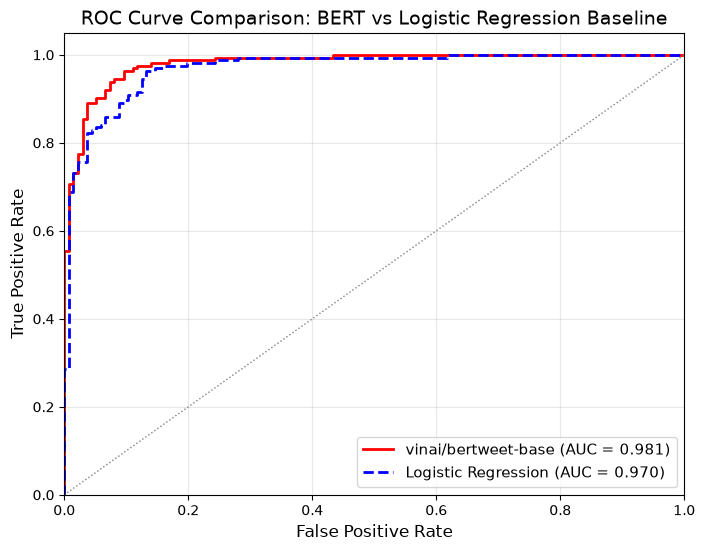

=== AUC Summary (source of truth for the report table) ===
Logistic Regression (TF-IDF): 0.970
bert-base-uncased:            0.973
vinai/bertweet-base: 0.981


In [13]:
# 3. ROC Curve & AUC Score Comparison
auc_bl = roc_auc_score(y_test_bl, y_prob_bl)
auc_m1 = roc_auc_score(y_test, probs_m1)
auc_bert = roc_auc_score(y_test, best_probs)

fpr_bl, tpr_bl, _ = roc_curve(y_test_bl, y_prob_bl)
fpr_bert, tpr_bert, _ = roc_curve(y_test, best_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bert, tpr_bert, color='red', lw=2, label=f'{best_bert_name} (AUC = {auc_bert:.3f})')
plt.plot(fpr_bl, tpr_bl, color='blue', lw=2, linestyle='--', label=f'Logistic Regression (AUC = {auc_bl:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: BERT vs Logistic Regression Baseline', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

print("=== AUC Summary (source of truth for the report table) ===")
print(f"Logistic Regression (TF-IDF): {auc_bl:.3f}")
print(f"bert-base-uncased:            {auc_m1:.3f}")
print(f"{best_bert_name}: {auc_bert:.3f}")

## 8. Attention Weights Analysis

In [14]:
def compute_attention_matrix(tokenizer, model, text):
    model.config._attn_implementation = "eager"
    model.config.output_attentions = True

    tokens = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to(model.device)
    with torch.no_grad():
        outputs = model(**tokens, output_attentions=True)

    # (num_layers, batch_size, num_heads, seq_len, seq_len)
    attentions = torch.stack(outputs.attentions).cpu().squeeze(1)
    attentions = attentions.mean(dim=0).mean(dim=0)  # mean of layer and head
    pred_class = outputs.logits.cpu().argmax(-1).item()
    token_strs = tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])
    return attentions, pred_class, token_strs


def filter_special_tokens(attentions, tokens, special_tokens):
    """Drop [CLS]/[SEP]/<s>/</s>-style tokens and renormalize so the attention-sink
    these tokens attract doesn't swamp the content-word pattern we actually care about."""
    keep_idx = [i for i, t in enumerate(tokens) if t not in special_tokens]
    filtered_tokens = [tokens[i] for i in keep_idx]
    sub = attentions[keep_idx][:, keep_idx]
    row_sums = sub.sum(dim=1, keepdim=True)
    row_sums[row_sums == 0] = 1.0
    sub = sub / row_sums
    return sub, filtered_tokens


def plot_attention_heatmap(attentions, tokens, title):
    plt.figure(figsize=(9, 7))
    plt.title(title, fontsize=12)
    sns.heatmap(
        attentions.numpy(),
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Blues',
        cbar=True
    )
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_top_attention_words(attentions, tokens, title, top_n=8):
    """Rank content tokens by total incoming attention to directly highlight the
    words driving the prediction, instead of reading them off a full heatmap."""
    scores = attentions.sum(dim=0).numpy()
    order = np.argsort(scores)[::-1][:top_n]
    words = [tokens[i] for i in order]
    vals = [scores[i] for i in order]
    plt.figure(figsize=(7, 4))
    plt.barh(words[::-1], vals[::-1], color='steelblue')
    plt.xlabel('Total incoming attention (content tokens only)')
    plt.title(title, fontsize=12)
    plt.tight_layout()
    plt.show()
    return list(zip(words, vals))

Sample Relevant Tweet:
irena estimates that green hydrogen could achieve price parity with blue hydrogen produced from fossil fuels within the next decade siew siew sg

Sample Irrelevant Tweet:
hydrogen responsive html template via urdu mag



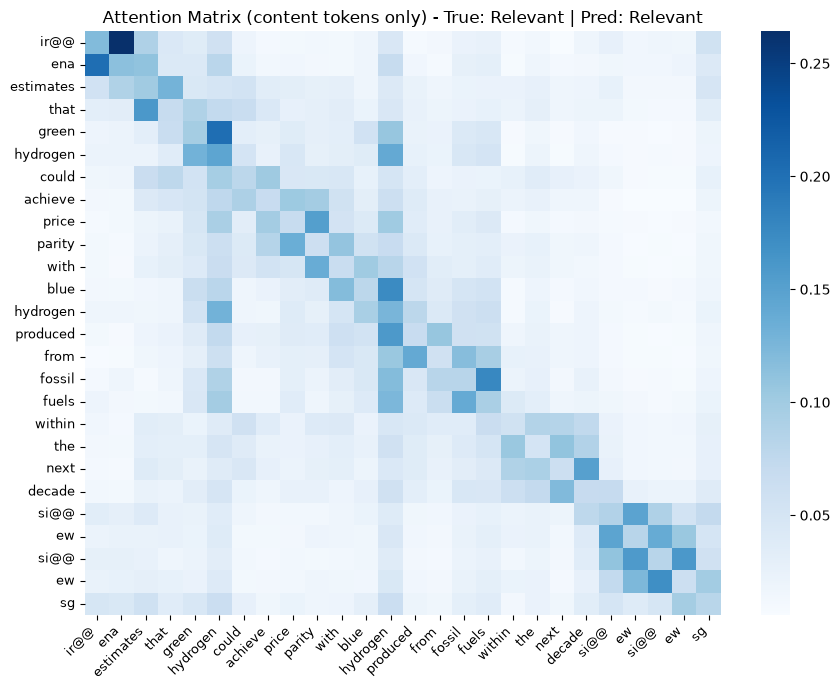

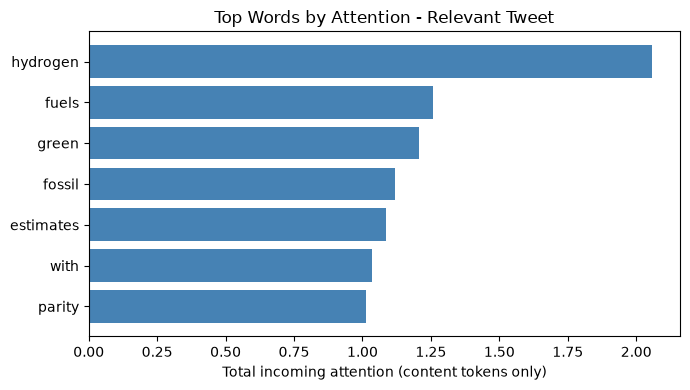

Top attended words (Relevant): [('hydrogen', 2.0570326), ('hydrogen', 1.9177812), ('fuels', 1.256831), ('green', 1.2049892), ('fossil', 1.1170151), ('estimates', 1.0851309), ('with', 1.0356135), ('parity', 1.0121034)]


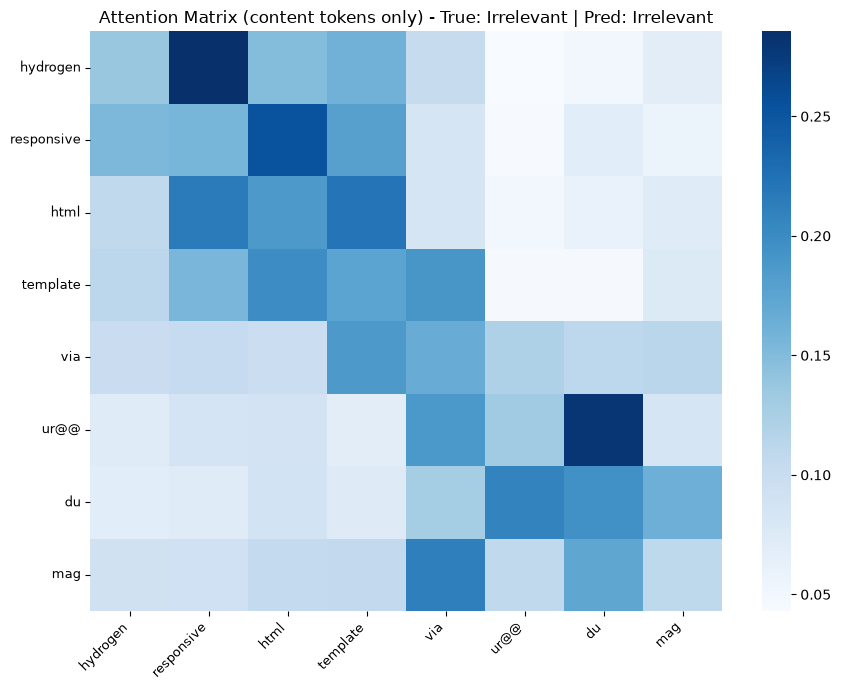

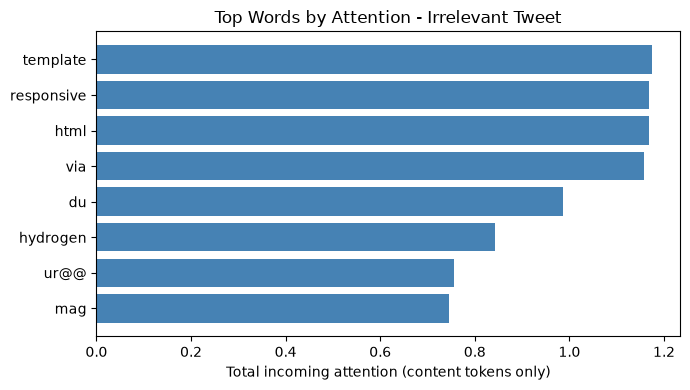

Top attended words (Irrelevant): [('template', 1.1750603), ('responsive', 1.1687741), ('html', 1.167883), ('via', 1.1577799), ('du', 0.9856555), ('hydrogen', 0.84344673), ('ur@@', 0.75497866), ('mag', 0.74642193)]


In [15]:
rel_idx = np.where(np.array(y_test) == 1)[0][0]
irrel_idx = np.where(np.array(y_test) == 0)[0][0]

sample_rel_text = X_test_raw[rel_idx]
sample_irrel_text = X_test_raw[irrel_idx]

print(f"Sample Relevant Tweet:\n{sample_rel_text}\n")
print(f"Sample Irrelevant Tweet:\n{sample_irrel_text}\n")

# Raw averaged attention is dominated by the attention-sink every transformer directs
# at its special tokens ([CLS]/[SEP] or <s>/</s>), which swamps any content-word signal.
# Drop those tokens and renormalize before visualizing so the heatmap/ranking actually
# reflects which words the model is using to decide the class.
special_tokens = set(best_tokenizer.all_special_tokens)

# 1. Relevant tweet
att_rel, pred_rel, tok_rel = compute_attention_matrix(best_tokenizer, best_model, sample_rel_text)
att_rel_f, tok_rel_f = filter_special_tokens(att_rel, tok_rel, special_tokens)
plot_attention_heatmap(
    att_rel_f,
    tok_rel_f,
    f"Attention Matrix (content tokens only) - True: Relevant | Pred: {'Relevant' if pred_rel == 1 else 'Irrelevant'}"
)
top_rel = plot_top_attention_words(att_rel_f, tok_rel_f, "Top Words by Attention - Relevant Tweet")
print("Top attended words (Relevant):", top_rel)

# 2. Irrelevant tweet
att_irrel, pred_irrel, tok_irrel = compute_attention_matrix(best_tokenizer, best_model, sample_irrel_text)
att_irrel_f, tok_irrel_f = filter_special_tokens(att_irrel, tok_irrel, special_tokens)
plot_attention_heatmap(
    att_irrel_f,
    tok_irrel_f,
    f"Attention Matrix (content tokens only) - True: Irrelevant | Pred: {'Relevant' if pred_irrel == 1 else 'Irrelevant'}"
)
top_irrel = plot_top_attention_words(att_irrel_f, tok_irrel_f, "Top Words by Attention - Irrelevant Tweet")
print("Top attended words (Irrelevant):", top_irrel)

### Task 9: Hydrogen Tweet Classification with BERT - Final Report

#### 1. Data Preprocessing Pipeline
* **Text Cleaning:** Raw tweets often contain noise such as URLs, user handles, non-ASCII characters, and irregular spacing. We applied regular expressions to strip out hyperlinks (`http\S+`), Twitter mentions (`@\w+`), and special symbols. Consecutive whitespaces were normalized into single spaces.
* **Label Encoding:** Categorical labels were mapped to binary integers where 'Relevant' was encoded as 1 (energy-related) and 'Irrelevant' as 0.
* **Tokenization:** Inputs were tokenized using model-specific tokenizers with truncation and dynamic padding up to a maximum length of 128 tokens, ensuring uniform tensor inputs for GPU training.

#### 2. Fine-Tuning BERT Models
* **Model Selection:**
  1. `bert-base-uncased`: A standard general-domain bidirectional transformer trained on Wikipedia and BookCorpus, serving as a reliable benchmark.
  2. `vinai/bertweet-base`: A domain-specific RoBERTa-based model pre-trained on 850 million English tweets, specifically optimized for Twitter slang, syntax, and informal phrasing.
* **Data Split Strategy:** A stratified 70/30 train-test split was applied (700 training samples, 300 test samples) using `random_state=42`. Stratification ensured that both subsets preserved the identical class distribution (54.7% Relevant, 45.3% Irrelevant).
* **Loss Function:** Standard Cross-Entropy Loss was employed via `AutoModelForSequenceClassification`. It is the optimal loss for binary classification as it heavily penalizes confident incorrect probability predictions through negative log-likelihood.
* **Hyperparameters & Architecture:** Both models utilized a sequence classification head (linear layer with dropout on top of the pooled `[CLS]` token). Hyperparameters included:
  - Epochs: 3
  - Batch Size: 16 (train), 32 (eval)
  - Learning Rate: 2e-5 (AdamW optimizer)
  - Weight Decay: 0.01 (L2 regularization)
* **Accuracy Results:**
  - `bert-base-uncased`: Training Accuracy = 96.00% | Testing Accuracy = 90.33%
  - `vinai/bertweet-base`: Training Accuracy = 96.86% | Testing Accuracy = 93.33%

#### 3. Comparison with Traditional Baseline (Logistic Regression)
* **Performance Summary Table:**

| Model | Test Accuracy | Precision (Relevant) | Recall (Relevant) | F1-Score (Relevant) | ROC-AUC |
| :--- | :---: | :---: | :---: | :---: | :---: |
| Logistic Regression (TF-IDF) | 89.67% | 0.86 | 0.98 | 0.91 | 0.970 |
| `bert-base-uncased` | 90.33% | 0.92 | 0.90 | 0.91 | 0.973 |
| `vinai/bertweet-base` (Best) | **93.33%** | **0.92** | **0.96** | **0.94** | **0.981** |

* **Discussion:**
  - BERT clearly outperformed the TF-IDF Logistic Regression baseline across all metrics (Test Accuracy increased from 89.67% to 93.33%, and AUC from 0.970 to 0.981).
  - *Why BERT Won:* All tweets in this dataset contain the keyword "hydrogen". The TF-IDF model treats words as independent bags-of-tokens and struggles when the discriminative signal depends on context. Conversely, BERT's multi-head self-attention captures deep bidirectional dependencies, distinguishing between "green/blue hydrogen" (clean energy) and "hydrogen responsive template" (computing/chemistry). Furthermore, `BERTweet` achieved the highest accuracy because its vocabulary was specifically pre-trained on social media text.

#### 4. Attention Weights Analysis
Using the best model (`vinai/bertweet-base`), we averaged attention weights across all layers and heads for sample test tweets. Raw averaged attention is dominated by the attention-sink every transformer directs at its `<s>`/`</s>` special tokens, which swamps any content-word signal, so `<s>`/`</s>` were excluded and the remaining attention renormalized before visualizing (see `filter_special_tokens`) -- the plots below and the "top attended words" ranking reflect only content-token attention.
* **Relevant Tweet:** *"irena estimates that green hydrogen could achieve price parity with blue hydrogen produced from fossil fuels within the next decade..."*
  - The content-token heatmap shows `green` attending most strongly to the first `hydrogen`, `blue` attending most strongly to the second `hydrogen`, and `fossil` attending most strongly to `fuels` -- the model links each energy-source modifier to its noun. The top-attention ranking confirms this: `hydrogen` (both occurrences), `fuels`, `green`, and `fossil` receive the most total incoming attention, and the model predicts Relevant with high confidence.
* **Irrelevant Tweet:** *"hydrogen responsive html template via urdu mag"*
  - The content-token heatmap shows `hydrogen` attending most strongly to `responsive`, and `responsive`/`html`/`template` forming a mutually-reinforcing cluster of attention among themselves. The top-attention ranking is led by `template`, `responsive`, and `html`, ahead of `hydrogen` itself -- the model recognizes "hydrogen" is modified by web-design terms rather than an energy-related word, and correctly predicts Irrelevant.
  